# Reference Mapping of WT and Mutant Midgut Cells


**Purpose**

This notebook performs a Harmony-based integration of wild-type (WT) and mutant single-cell RNA-seq datasets to:

1. identify midgut cell populations within the full datasets,

2. annotate the major midgut regions (AMG, MMG, and PMG), and

3. map LanB2 and tinman mutant cells onto the WT midgut reference to assess cell-type correspondence.



**Input**

The full WT dataset integrated with Harmony
Processed LanB2 and tinman mutant datasets
A curated set of WT midgut cells used as the reference for mapping


**Workflow overview**

In the first part of the notebook, Harmony integration is used to jointly embed the WT, LanB2, and tinman datasets. This integrated space is used to identify clusters corresponding to midgut cells, based on known markers. 
In the second part, the WT midgut cells are used as a reference atlas. LanB2 and tinman mutant midgut cells are then mapped onto this reference to transfer cell-type annotations and to compare how mutant cells align with WT anterior, middle, and posterior midgut identities.


**Output**

* UMAP embeddings of the full integrated dataset colored by major cell types
* Identified midgut cells in LanB2 and tinman mutants with assigned AMG/MMG/PMG identities together with the UMAP embeddings


**Saved files**

`mg_wt_tin_lan_refmap.h5ad` concatenated AnnData object containing WT and mutant midgut cells with transferred annotations



In [ ]:
import os
import random

import numpy as np
import pandas as pd
import scanpy as sc

#import scvelo as scv

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

from scipy.sparse import csr_matrix, issparse

from scipy import io

sc.settings.set_figure_params(dpi=80, frameon=False)
sc.set_figure_params(dpi=80)
sc.set_figure_params(figsize=(4, 4))
plt.rcParams['figure.dpi'] = 80
plt.rcParams['figure.figsize'] = (4, 4)

from scipy.sparse import csr_matrix, issparse

In [ ]:
SEED = 0

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
wt = sc.read('../data/processed/WT_Harmony.h5ad')
wt

In [ ]:
wt.obs['celltype'] = wt.obs['celltype'].replace({'midgut_ICPs':'midgut'})

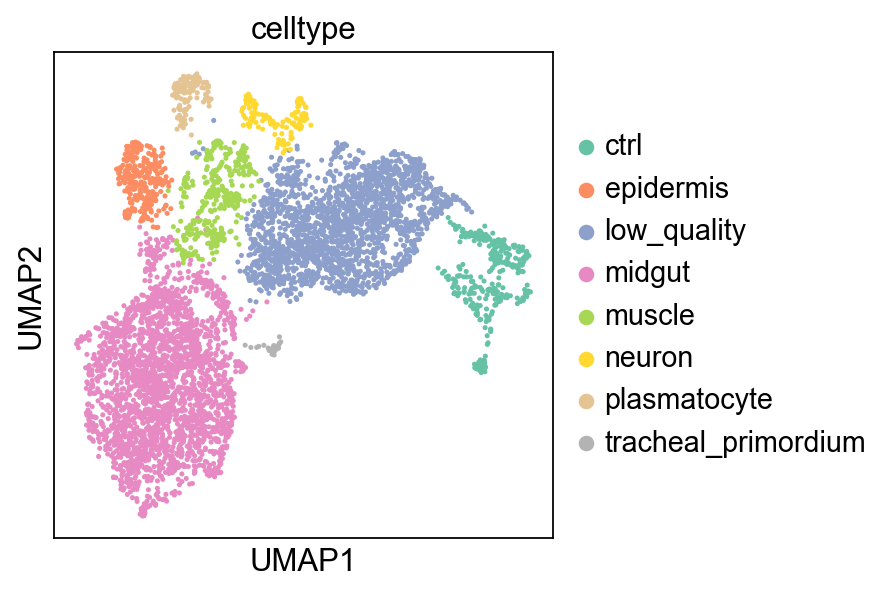

In [5]:
sc.pl.umap(wt, color='celltype', palette="Set2", show=False)
plt.savefig("../figures/whole_dataset.pdf", bbox_inches="tight",
    dpi=300)

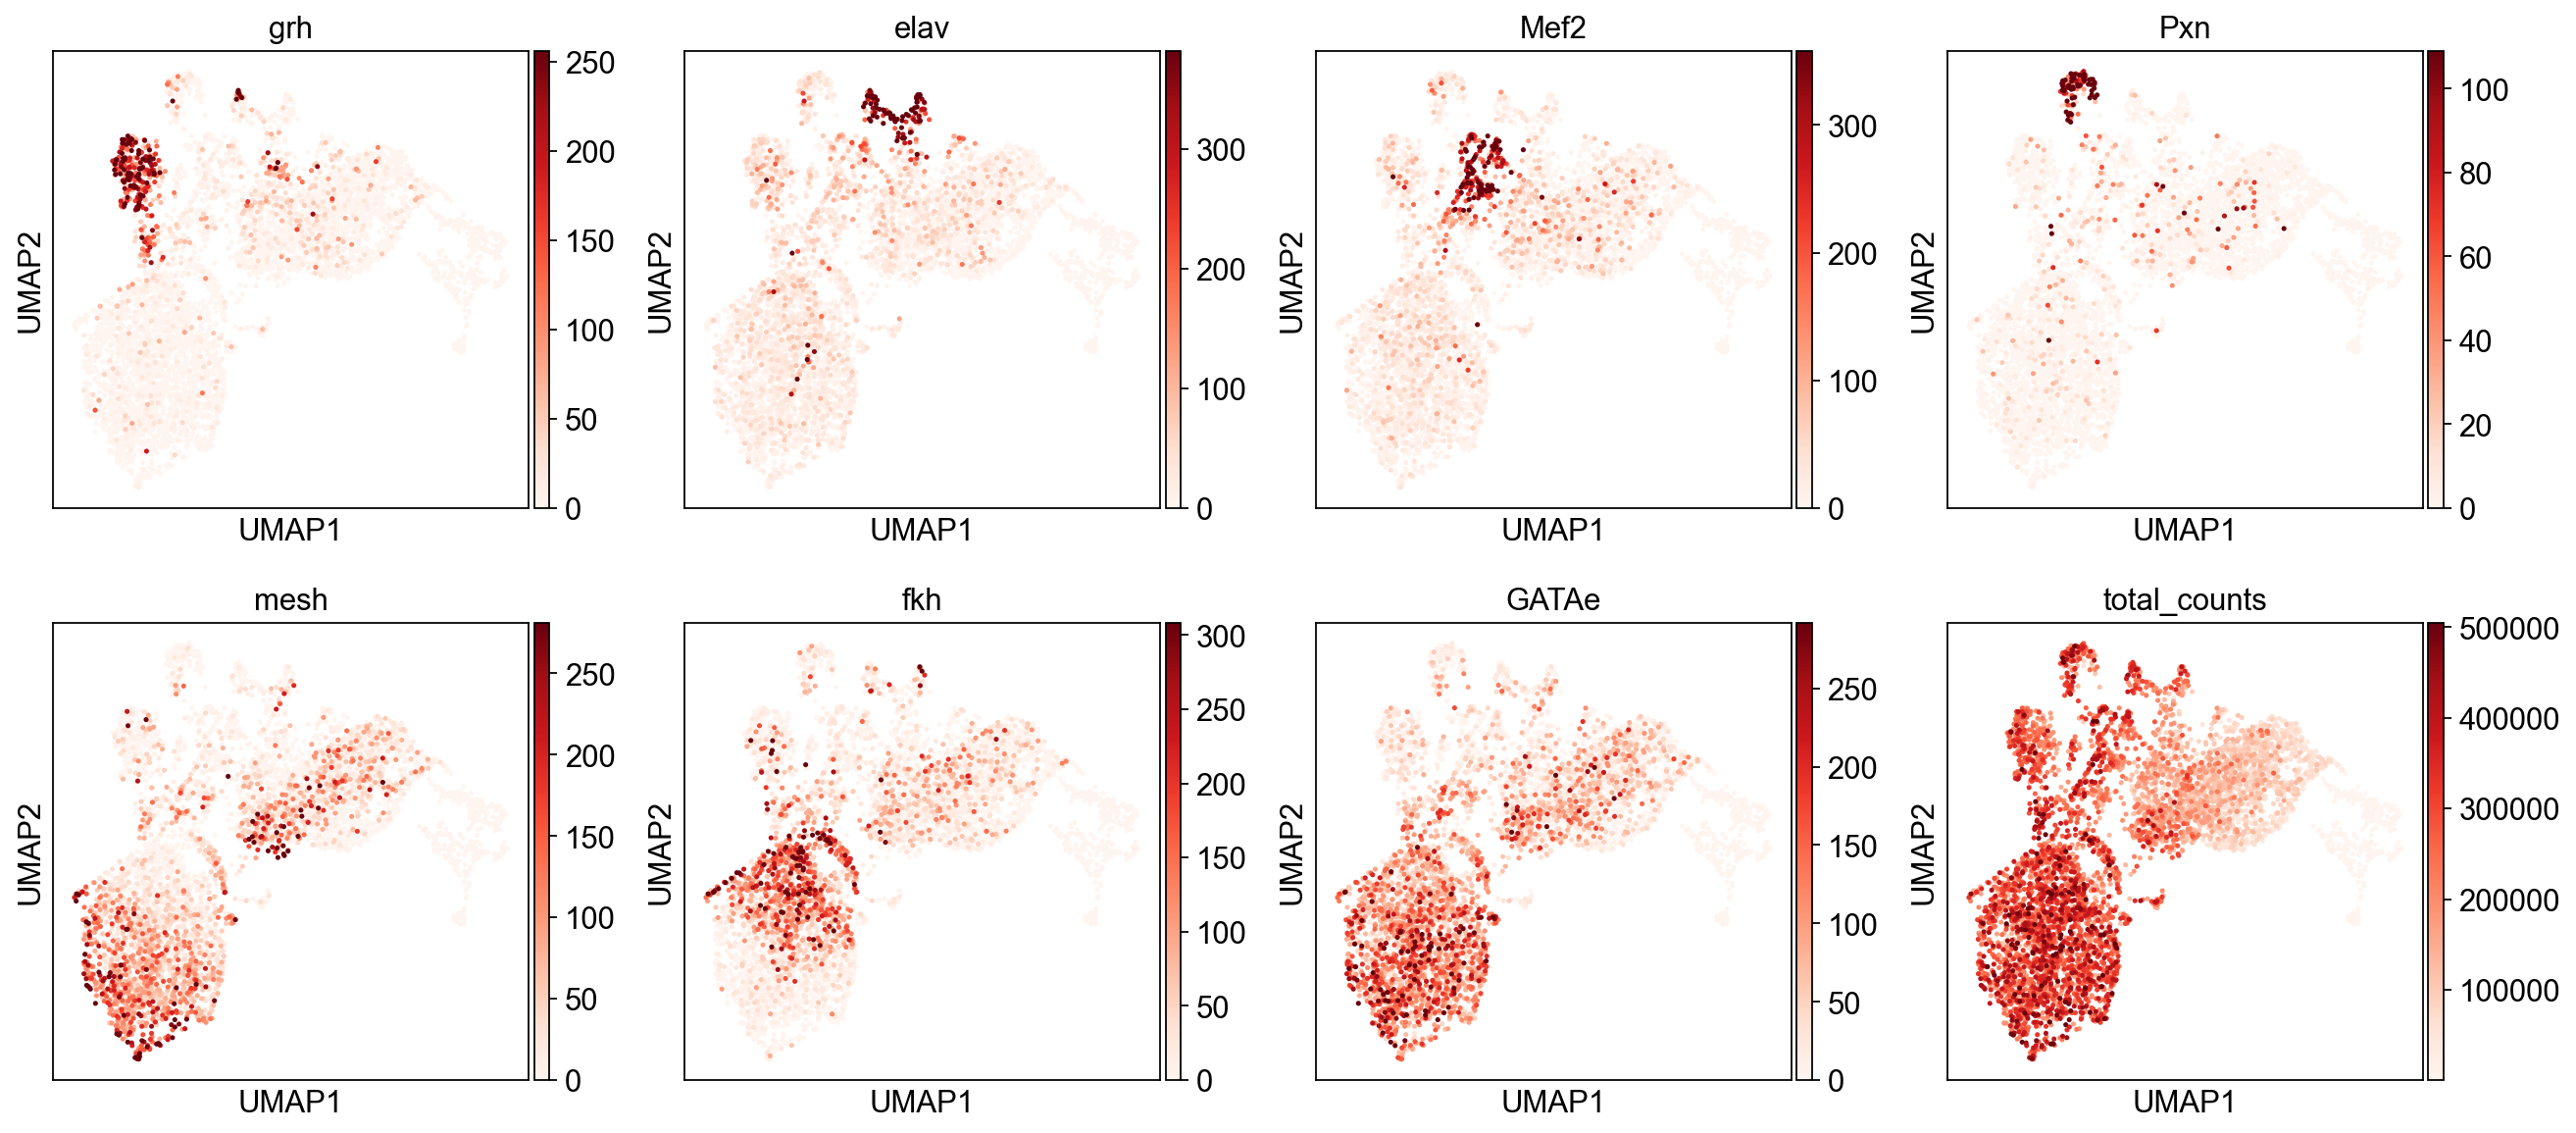

In [6]:
sc.pl.umap(wt, color=['grh', 'elav', 'Mef2', 'Pxn', 'mesh', 'fkh', 'GATAe', 'total_counts'], cmap='Reds', vmax='p99')

In [ ]:
wt.X = wt.layers['raw_counts']
wt.X

In [ ]:
chip6 = wt[wt.obs['batch']=='WT_01']
chip6

In [ ]:
chip7 = wt[wt.obs['batch']=='WT_02']
chip7

In [ ]:
chip8 = wt[wt.obs['batch']=='WT_03']
chip8

In [ ]:
chip9 = wt[wt.obs['batch']=='WT_04']
chip9

In [ ]:
tin = sc.read('../data/processed/mutant_tin_Harmony.h5ad')
tin

In [ ]:
tin.X = tin.layers['raw_counts']
tin.X

In [ ]:
tin1 = tin[tin.obs['batch']=='0']
tin1

In [ ]:
tin2 = tin[tin.obs['batch']=='1']
tin2

In [ ]:
sc.pl.umap(tin, color='celltype')

In [ ]:
lan = sc.read('../data/processed/mutant_LanB2_Harmony.h5ad')
lan

In [ ]:
lan.X = lan.layers['raw_counts']
lan.X

In [ ]:
lan1 = lan[lan.obs['batch']=='0']
lan1

In [ ]:
lan2 = lan[lan.obs['batch']=='1']
lan2

In [ ]:
sc.pl.umap(lan, color='celltype')

In [ ]:
lan.X

In [ ]:
chip6.obs['dataset']='wild-type'
chip7.obs['dataset']='wild-type'
chip8.obs['dataset']='wild-type'
chip9.obs['dataset']='wild-type'
tin1.obs['dataset']='tin'
tin2.obs['dataset']='tin'
lan1.obs['dataset'] = 'LanB2'
lan2.obs['dataset'] = 'LanB2'

In [ ]:
adata = chip6.concatenate(chip7, chip8, chip9, tin1, tin2, lan1, lan2, batch_key='batch', batch_categories=['WT_01', 'WT_02', 'WT_03', 'WT_04', 'tin_01', 'tin_02', 'LanB_01', 'LanB_02'])
adata

In [ ]:
adata.X

In [ ]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=4000, batch_key='batch')

In [ ]:
gene = 'tin'

if gene in adata.var_names:
    is_highly_variable = adata.var.loc[gene, 'highly_variable']
    if is_highly_variable:
        print (f"{gene} is a highly variable gene")
    else:
        print(f"{gene} is NOT a highly variable")
else:
    print (f"{gene} is NOT a variable")

In [ ]:
gene = 'LanB2'

if gene in adata.var_names:
    is_highly_variable = adata.var.loc[gene, 'highly_variable']
    if is_highly_variable:
        print (f"{gene} is a highly variable gene")
    else:
        print(f"{gene} is NOT a highly variable")
else:
    print (f"{gene} is NOT a variable")

In [ ]:
sc.pp.pca(adata, n_comps=30, use_highly_variable=True)

In [ ]:
sc.external.pp.harmony_integrate(adata, key='batch')

In [ ]:
sc.pp.neighbors(adata, use_rep='X_pca_harmony')

In [ ]:
sc.tl.umap(adata)

In [ ]:
sc.pl.umap(adata, color=['total_counts', 'batch', 'celltype', 'dataset'], wspace=0.5)

In [ ]:
sc.tl.leiden(adata, resolution=0.1, key_added='leiden_0.1')
sc.tl.leiden(adata, resolution=0.15, key_added='leiden_0.15')
sc.tl.leiden(adata, resolution=0.2, key_added='leiden_0.2')
sc.tl.leiden(adata, resolution=0.3, key_added='leiden_0.3')
sc.tl.leiden(adata, resolution=0.4, key_added='leiden_0.4')
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_0.5')

In [ ]:
sc.pl.umap(adata, color=['leiden_0.1', 'leiden_0.15', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5'])

In [ ]:
# this is just for showing the expression of tin and LanB2 
adata_raw = adata.raw.to_adata()

In [ ]:
wt_sub = adata_raw[adata_raw.obs['dataset']=='wild-type']

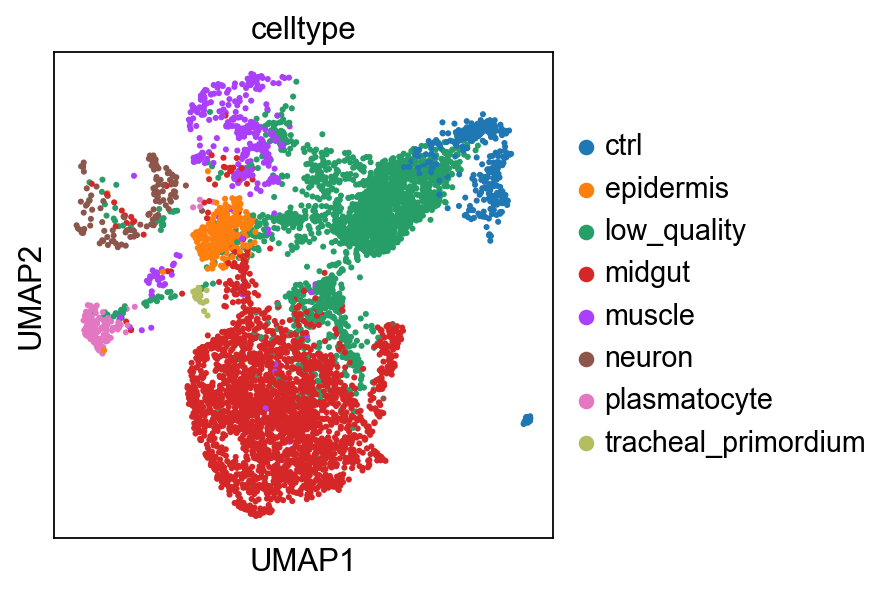

In [39]:
sc.pl.umap(wt_sub, color=['celltype'], size=30)

In [ ]:
sc.pl.umap(wt_sub, color=['tin'], cmap='Reds', vmax='p99', size=30, frameon=False)

In [ ]:
sc.pl.umap(wt_sub, color=['LanB2'], cmap='Reds', vmax='p99', size=30, frameon=False)

In [ ]:
tin_sub = adata_raw[adata_raw.obs['dataset']=='tin']

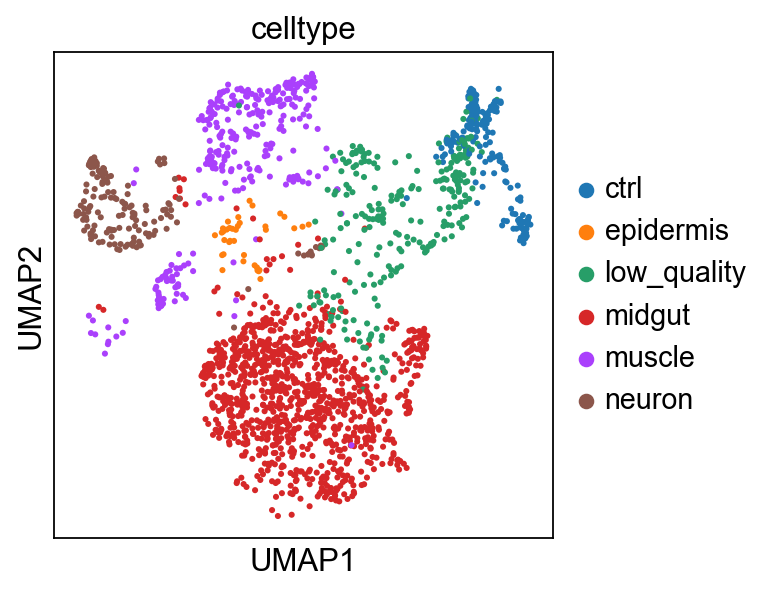

In [43]:
sc.pl.umap(tin_sub, color=['celltype'], size=30)

In [ ]:
sc.pl.umap(tin_sub, color=['tin'], cmap='Reds', vmax='p99', size=30, frameon=False)

In [ ]:
sc.pl.umap(tin_sub, color=['LanB2'], cmap='Reds', vmax='p99', size=30, frameon=False)

In [ ]:
lan_sub = adata_raw[adata_raw.obs['dataset']=='LanB2']

In [ ]:
lan_sub.X

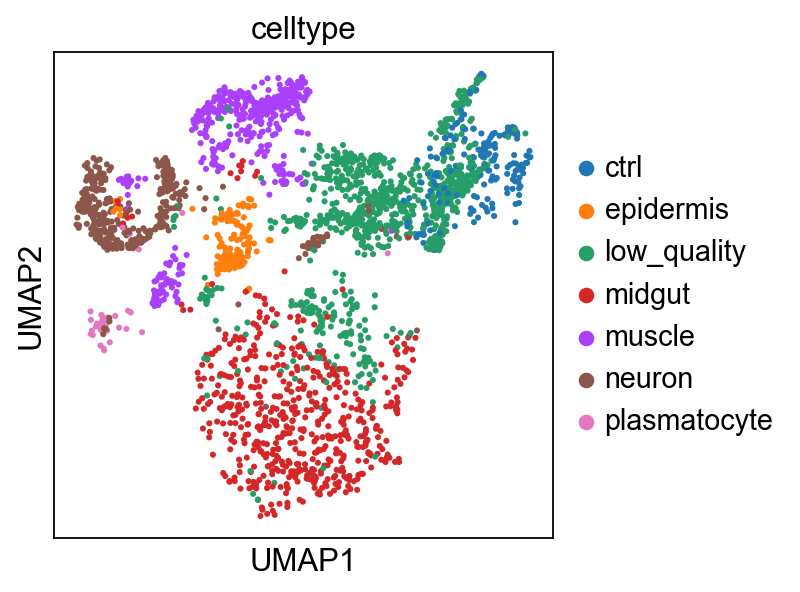

In [48]:
sc.pl.umap(lan_sub, color=['celltype'], size=30)

In [ ]:
sc.pl.umap(lan_sub, color=['tin'], cmap='Reds', vmax='p99', size=30, frameon=False)

In [ ]:
sc.pl.umap(lan_sub, color=['LanB2'], cmap='Reds', vmax='p99', size=30, frameon=False)

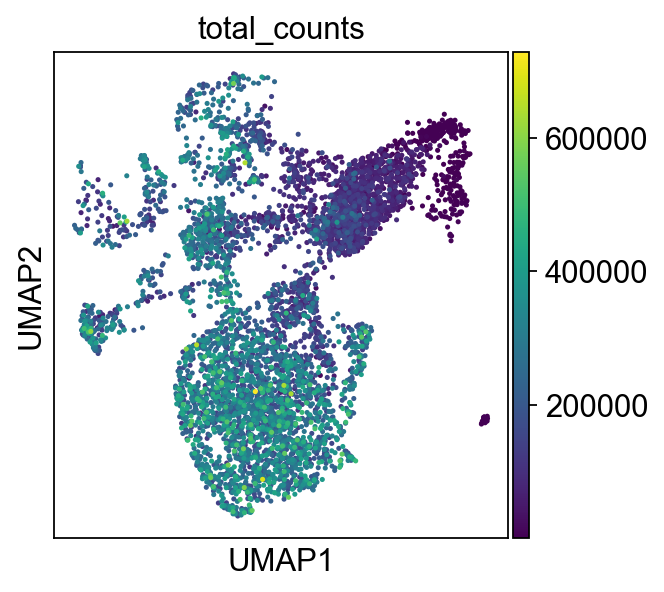

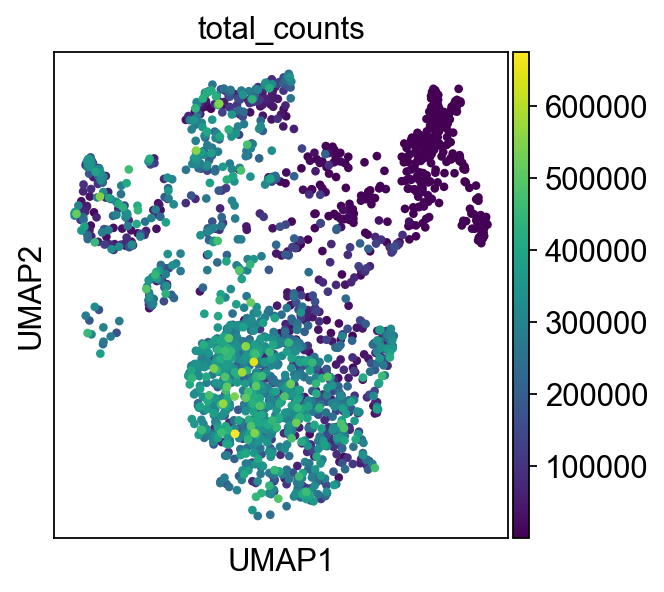

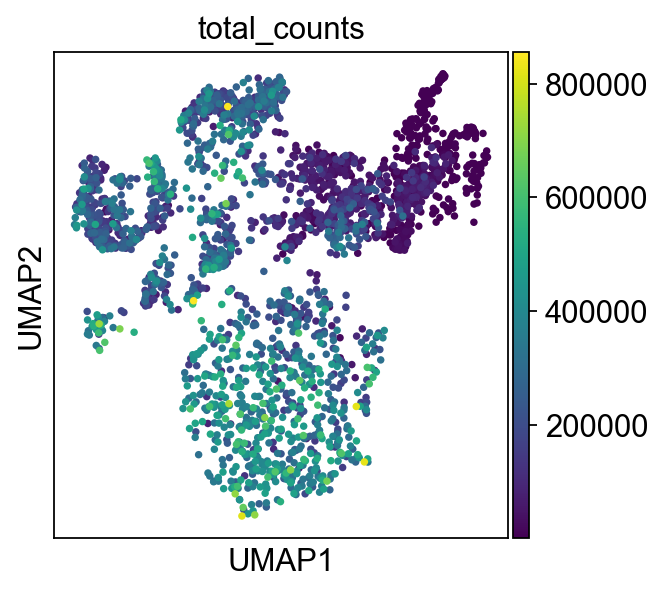

In [51]:
p1 = sc.pl.umap(wt_sub, color='total_counts')
p2 = sc.pl.umap(tin_sub, color='total_counts')
p3 = sc.pl.umap(lan_sub, color='total_counts')

### Subsetting midgut and reference mapping 

'''For reference mapping I use the WT midgut dataset that was generated before'''

In [ ]:
wt_mg = sc.read('../data/processed/mg_6_7_8_9_velo_refint.h5ad')
wt_mg

In [ ]:
wt_mg.X = wt_mg.layers['raw_counts'].copy()
wt_mg.X

In [ ]:
gene = 'LanB2'

if gene in wt_mg.var_names:
    is_highly_variable = wt_mg.var_names[gene]
    if is_highly_variable:
        print (f"{gene} is a highly variable gene")
    else:
        print(f"{gene} is NOT a highly variable")
else:
    print (f"{gene} is NOT a variable")

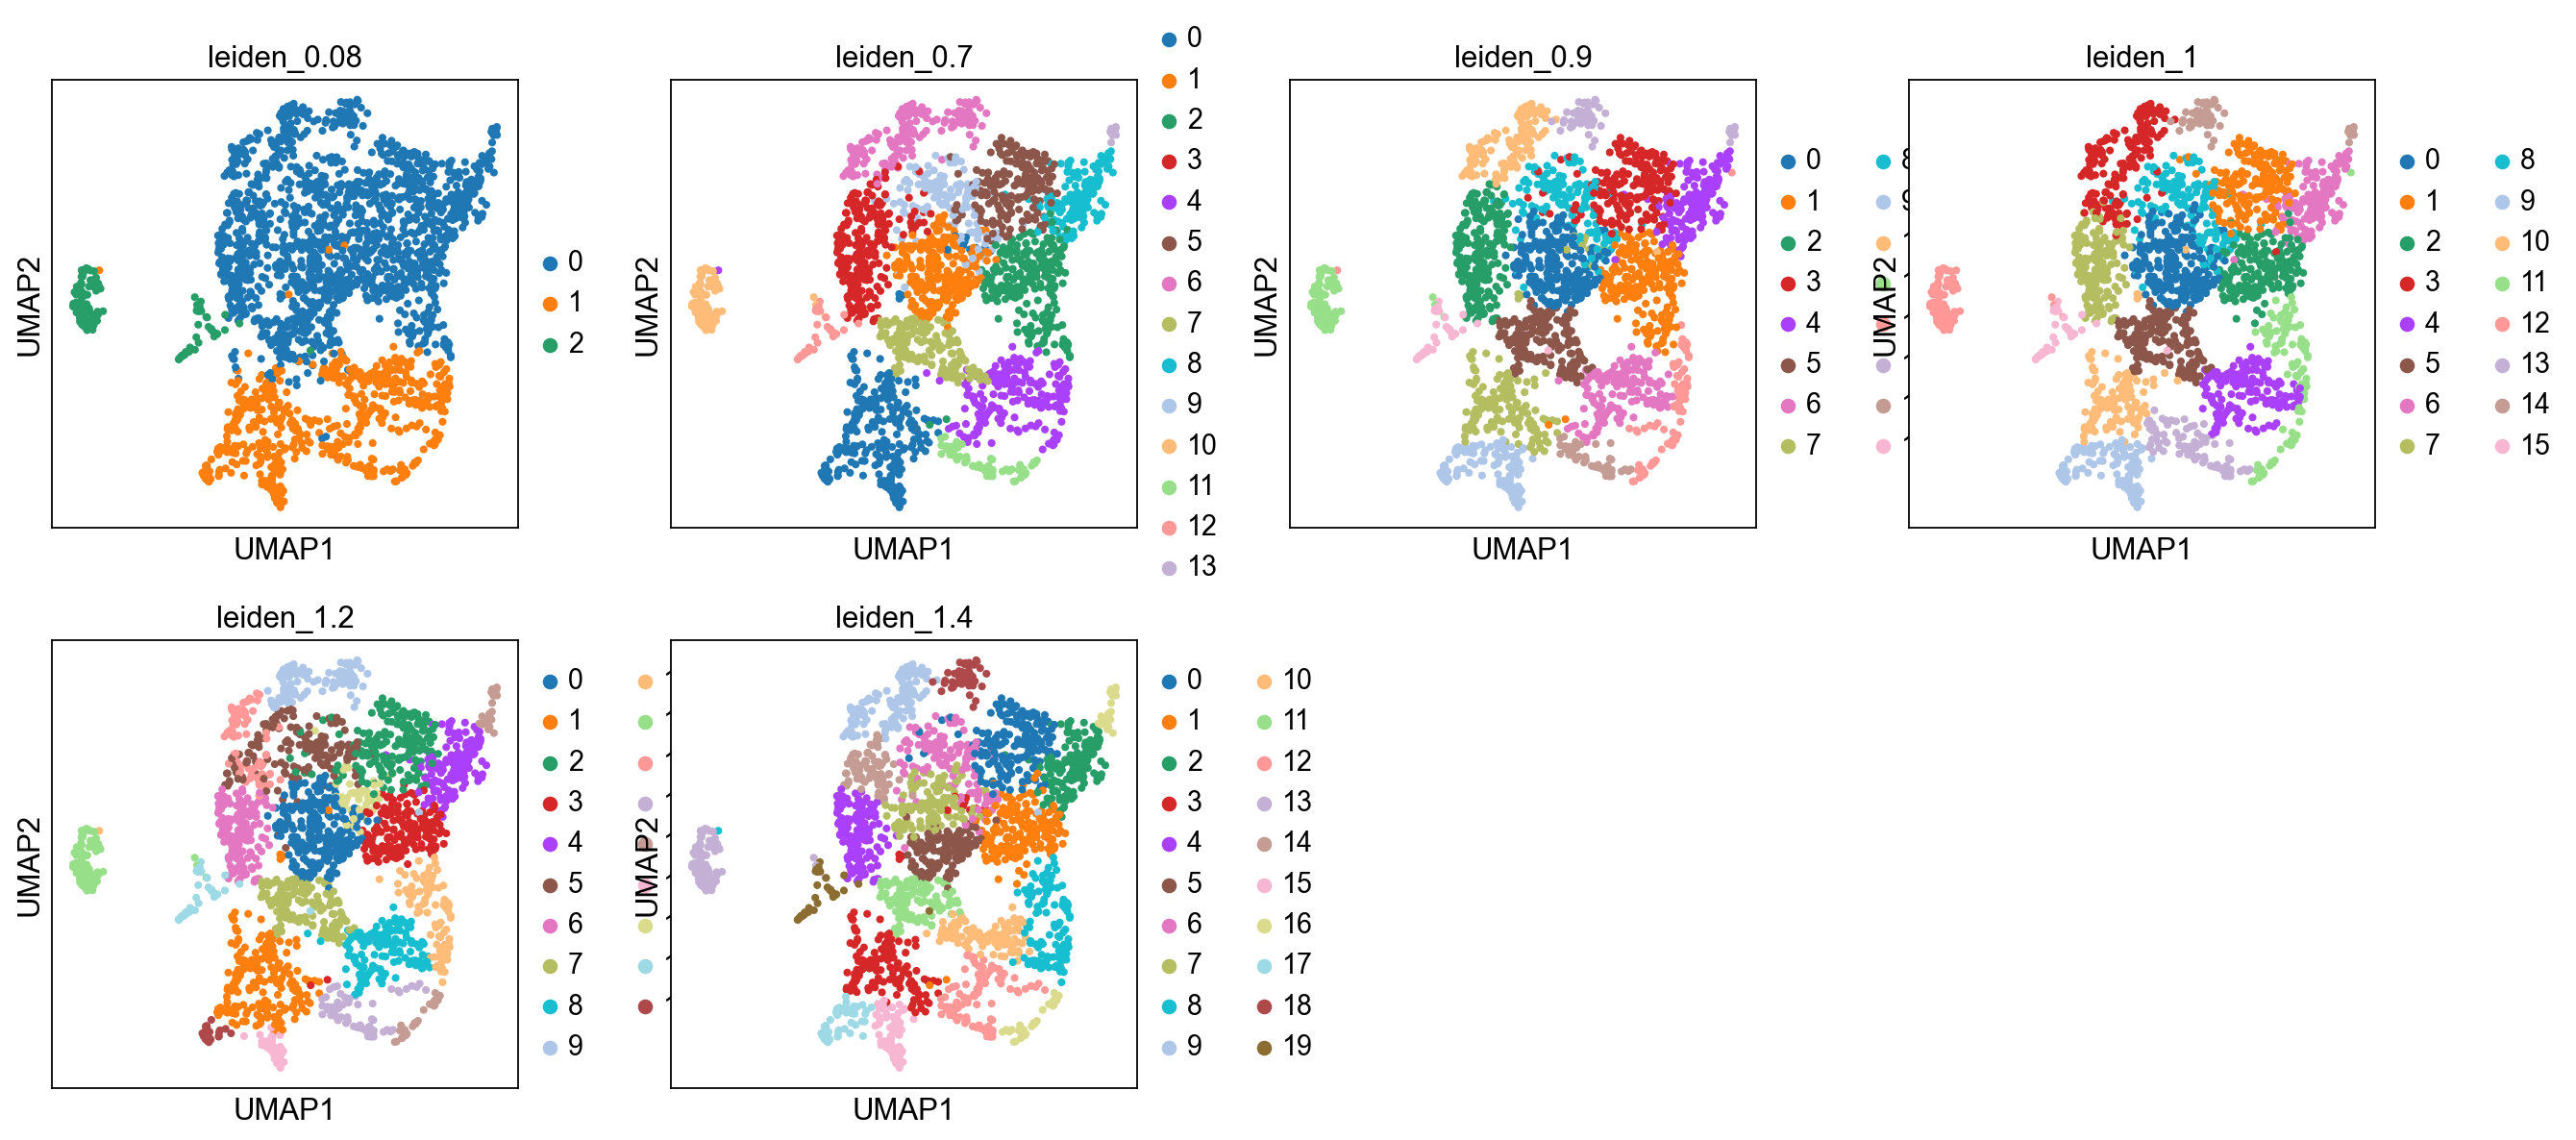

In [55]:
sc.pl.umap(wt_mg, color=['leiden_0.08','leiden_0.7', 'leiden_0.9', 'leiden_1', 'leiden_1.2', 'leiden_1.4'])

In [ ]:
sc.tl.leiden(wt_mg, restrict_to=['leiden_0.08', ['1']], resolution=0.1, key_added='leiden_sub')

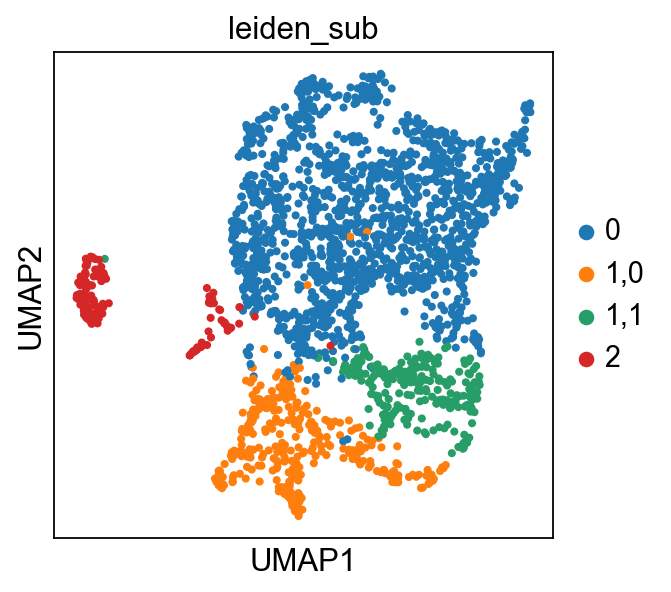

In [57]:
sc.pl.umap(wt_mg, color='leiden_sub')

In [ ]:
sc.tl.leiden(wt_mg, restrict_to=['leiden_sub', ['2']], resolution=0.1, key_added='leiden_sub_2x')

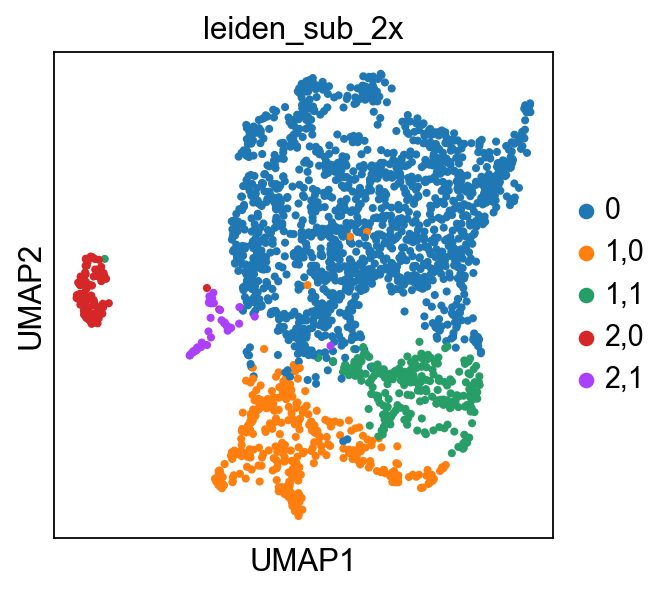

In [59]:
sc.pl.umap(wt_mg, color='leiden_sub_2x')

In [ ]:
midgut_celltype = {'0':'PMG', '1,0':'AMG', '1,1':'MMG', '2,0':'ICPs', '2,1':'zfh1+'}

In [ ]:
wt_mg.obs['midgut_celltype'] = wt_mg.obs['leiden_sub_2x'].map(midgut_celltype)

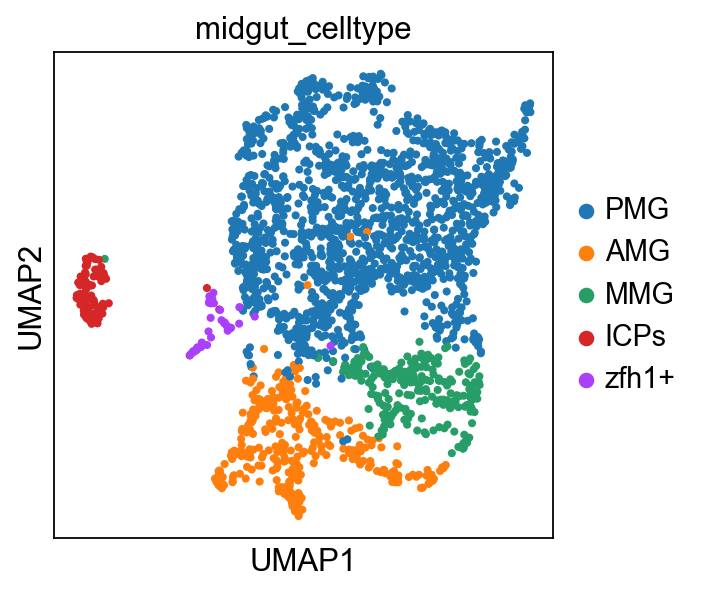

In [62]:
sc.pl.umap(wt_mg, color='midgut_celltype', show=False)
plt.savefig(
    "../figures/wt_mg.pdf",
    bbox_inches="tight",
    dpi=300
)

In [ ]:
wt_mg_raw = wt_mg.raw.to_adata()

In [ ]:
sc.pp.normalize_total(wt_mg_raw)
sc.pp.log1p(wt_mg_raw)

In [ ]:
sc.tl.rank_genes_groups(wt_mg_raw, groupby="midgut_celltype", method="wilcoxon", use_raw=False)

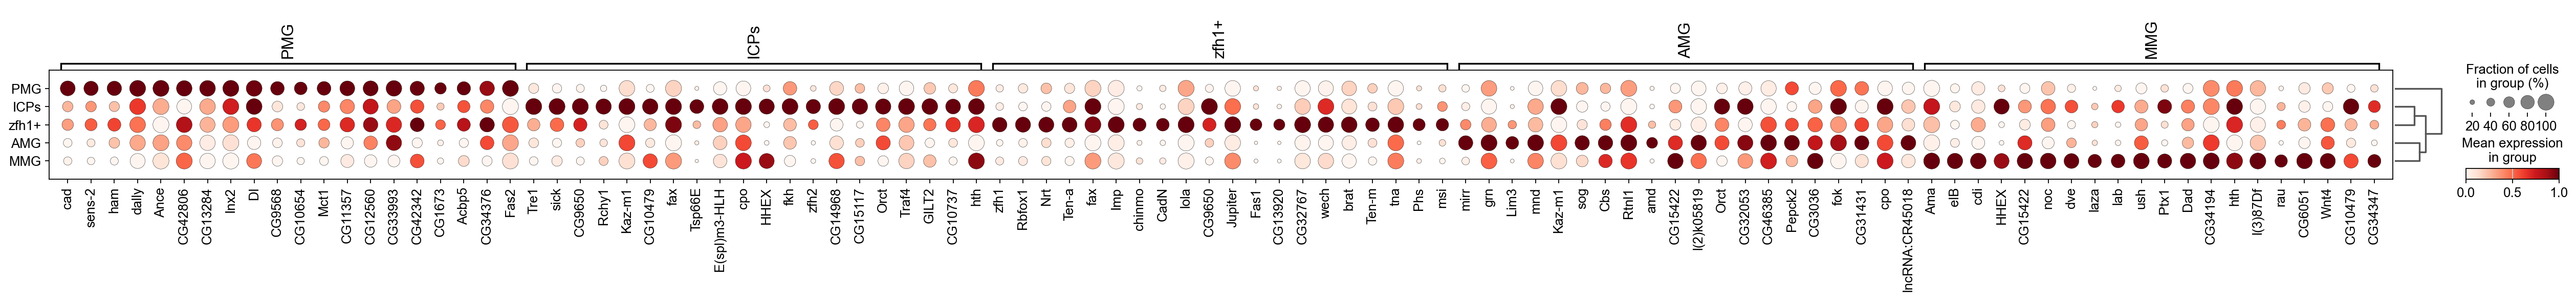

In [66]:
sc.pl.rank_genes_groups_dotplot(wt_mg_raw,  n_genes=20, standard_scale="var")

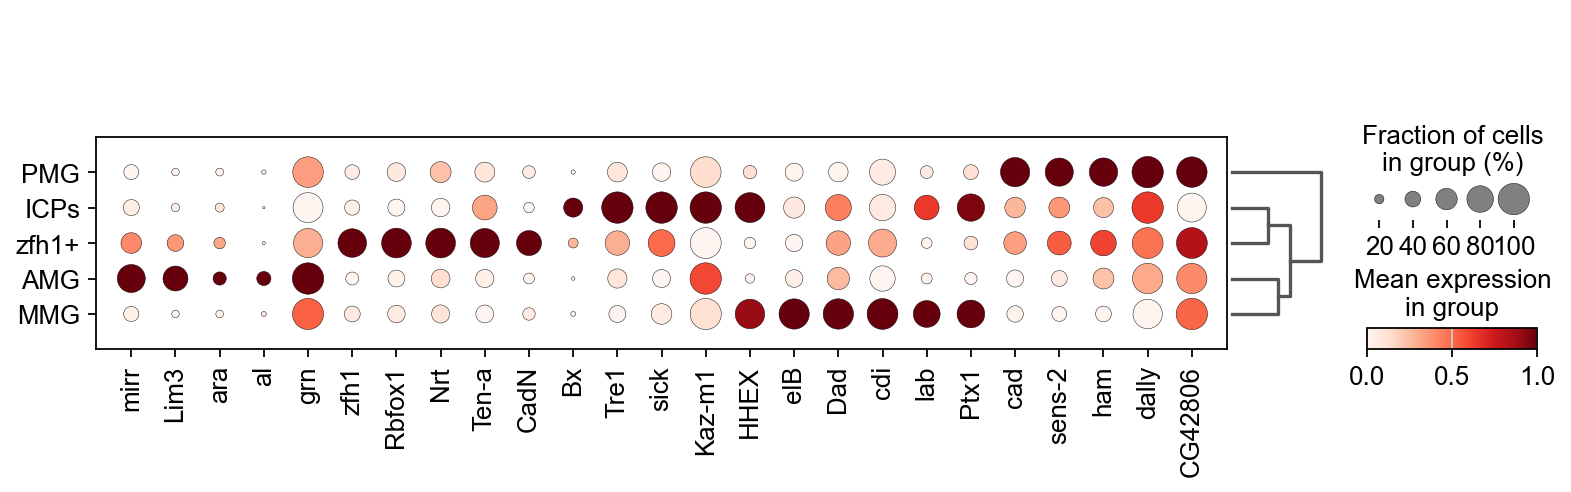

In [67]:
sc.pl.dotplot(wt_mg_raw, groupby='midgut_celltype', var_names=['mirr', 'Lim3', 'ara', 'al', 'grn',
                                                               'zfh1', 'Rbfox1', 'Nrt', 'Ten-a', 'CadN',
                                                               'Bx', 'Tre1', 'sick', 'Kaz-m1', 'HHEX', 
                                                               'elB', 'Dad', 'cdi', 'lab', 'Ptx1',
'cad', 'sens-2', 'ham', 'dally', 'CG42806'], standard_scale='var', show=False, dendrogram=True)
plt.savefig("../figures/dotplot_mgcelltype.pdf", bbox_inches='tight', dpi=300)

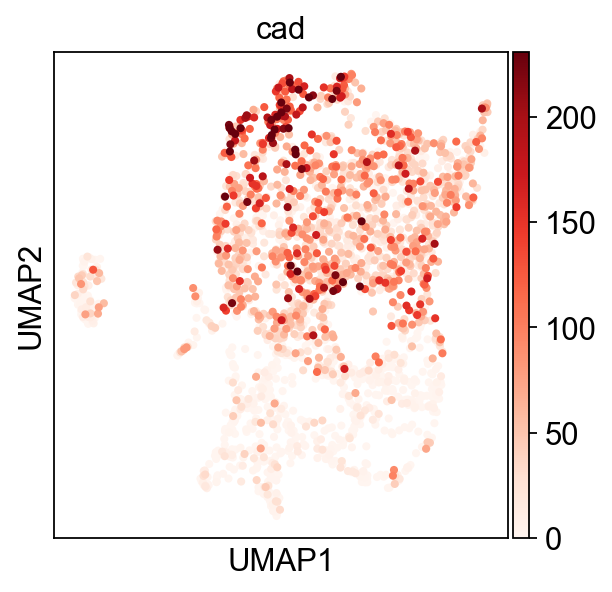

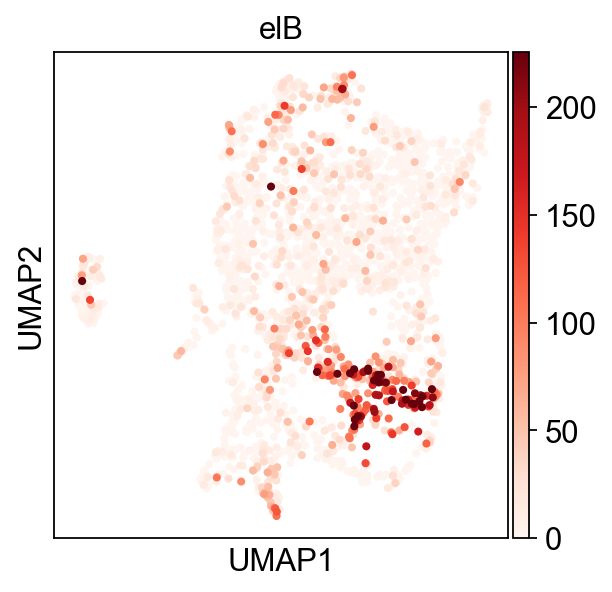

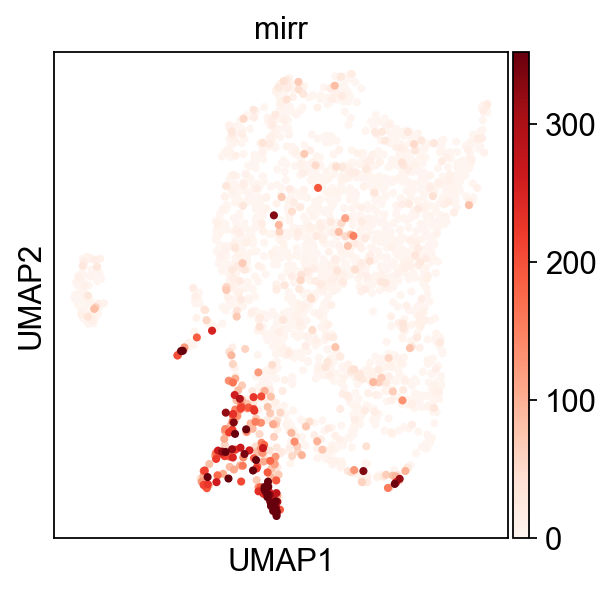

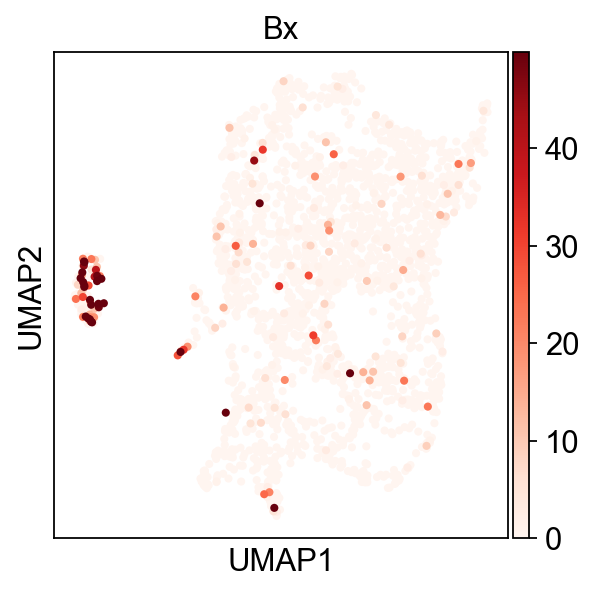

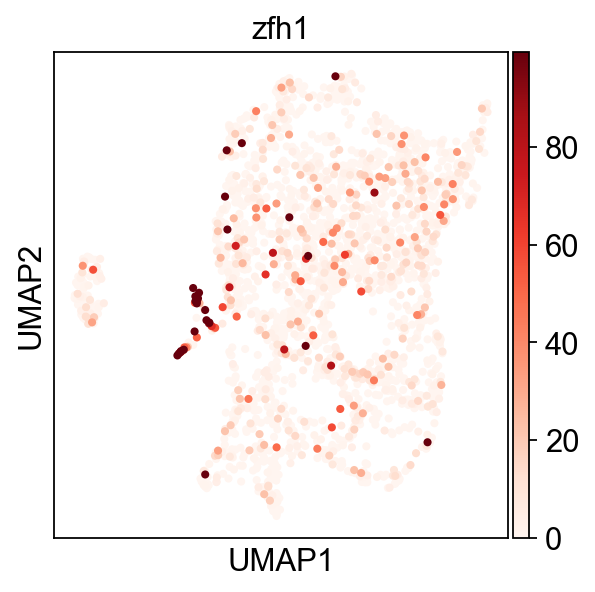

In [68]:
sc.pl.umap(wt_mg, color='cad', cmap='Reds', vmax='p99', show=False)
plt.savefig("../figures/wt_expr_cad.pdf", bbox_inches='tight', dpi=300)
sc.pl.umap(wt_mg, color='elB', cmap='Reds', vmax='p99', show=False)
plt.savefig("../figures/wt_expr_elB.pdf", bbox_inches='tight', dpi=300)
sc.pl.umap(wt_mg, color='mirr', cmap='Reds', vmax='p99', show=False)
plt.savefig("../figures/wt_expr_mirr.pdf", bbox_inches='tight', dpi=300)
sc.pl.umap(wt_mg, color='Bx', cmap='Reds', vmax='p99', show=False)
plt.savefig("../figures/wt_expr_Bx.pdf", bbox_inches='tight', dpi=300)
sc.pl.umap(wt_mg, color='zfh1', cmap='Reds', vmax='p99', show=False)
plt.savefig("../figures/wt_expr_zfh1.pdf", bbox_inches='tight', dpi=300)

In [ ]:
#tin_sub.raw = tin_sub.copy()
#lan_sub = lan_sub.copy()

In [ ]:
tin_mg = tin_sub[tin_sub.obs['leiden_0.3'].isin(['0', '3'])]
tin_mg

In [ ]:
lan_mg = lan_sub[lan_sub.obs['leiden_0.3'].isin(['0', '3'])]
lan_mg


In [ ]:
print(tin_mg.X)
print(lan_mg.X)

In [ ]:
wt_mg.obs['dataset'] = 'WT'
lan_mg.obs['dataset'] = 'LanB2'
tin_mg.obs['dataset'] = 'tin'

mg = wt_mg.concatenate(lan_mg, tin_mg, index_unique=None)
mg.obs

In [ ]:
sc.pp.normalize_total(mg)
sc.pp.log1p(mg)

In [ ]:
wt_mg_sub = mg[mg.obs['dataset']=='WT']
wt_mg = wt_mg[:, mg.var_names]
wt_mg.X = wt_mg_sub.X.copy()

In [ ]:
tin_mg_sub = mg[mg.obs['dataset']=='tin']
tin_mg = tin_mg[:, mg.var_names]
tin_mg.X = tin_mg_sub.X.copy()

In [ ]:
lan_mg_sub = mg[mg.obs['dataset']=='LanB2']
lan_mg = lan_mg[:, mg.var_names]
lan_mg.X = lan_mg_sub.X.copy()

In [ ]:
sc.tl.ingest(tin_mg, wt_mg, obs="leiden_1.4")

In [ ]:
tin_mg.uns["leiden_1.4_colors"]=wt_mg.uns["leiden_1.4_colors"]

In [ ]:
p1 = sc.pl.umap(wt_mg, color='leiden_1.4')
p2 = sc.pl.umap(tin_mg, color='leiden_1.4')

In [ ]:
sc.tl.ingest(lan_mg, wt_mg, obs="leiden_1.4")

In [ ]:
sc.pl.umap(lan_mg, color='leiden_1.4')

In [ ]:
sc.tl.ingest(tin_mg, wt_mg, obs="midgut_celltype")

In [ ]:
sc.tl.ingest(lan_mg, wt_mg, obs="midgut_celltype")

In [ ]:
# get UMAP coords from each object
X_wt  = wt_mg.obsm["X_umap"]
X_tin = tin_mg.obsm["X_umap"]
X_lan = lan_mg.obsm["X_umap"]

# global min/max across all three (optionally add a small padding)
X_all = np.vstack([X_wt, X_tin, X_lan])
xmin, ymin = X_all.min(axis=0)
xmax, ymax = X_all.max(axis=0)

pad = 0.02  # 2% padding
dx, dy = (xmax - xmin), (ymax - ymin)
xlim = (xmin - pad*dx, xmax + pad*dx)
ylim = (ymin - pad*dy, ymax + pad*dy)

def umap_fixed(adata, title=None):
    ax = sc.pl.umap(
        adata,
        color="midgut_celltype",
        frameon=False,
        size=50,
        show=False,
        title=title,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")  # keeps geometry consistent
    return ax


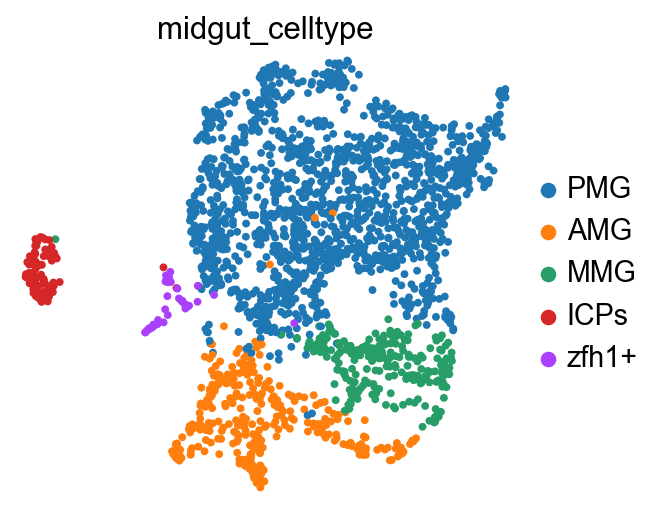

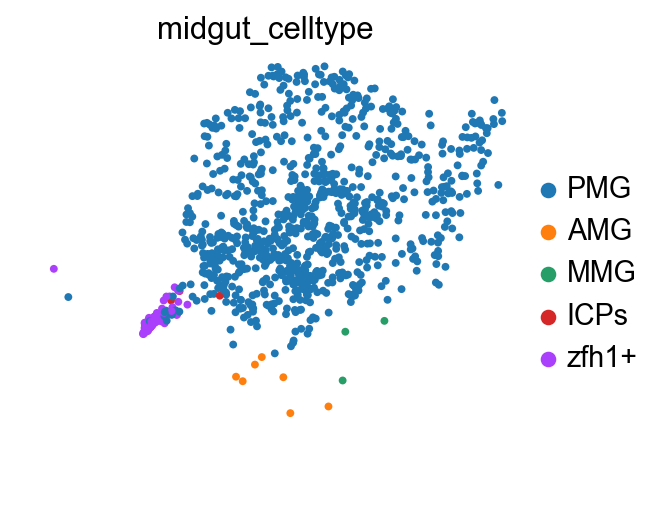

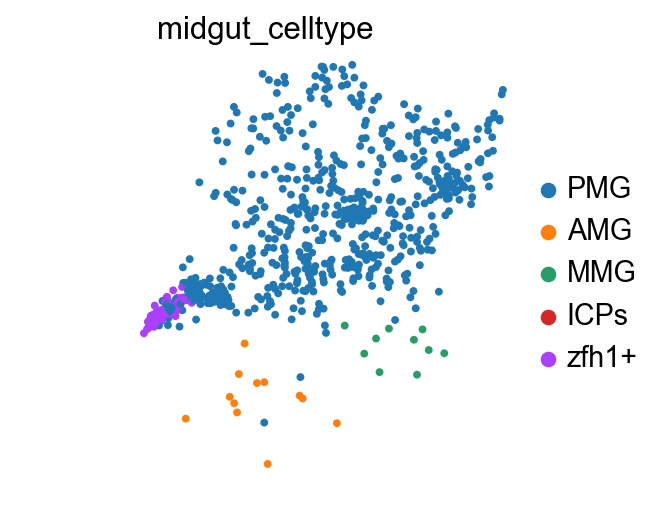

In [100]:
umap_fixed(wt_mg)
plt.savefig("../figures/ref_mapping_wt.pdf", bbox_inches="tight", dpi=300)
umap_fixed(tin_mg)
plt.savefig("../figures/ref_mapping_tin.pdf", bbox_inches="tight", dpi=300)
umap_fixed(lan_mg)
plt.savefig("../figures/ref_mapping_lan.pdf", bbox_inches="tight", dpi=300)

In [ ]:
mg_ref_mapping = wt_mg.concatenate(tin_mg, lan_mg, index_unique=None)

In [ ]:
mg_ref_mapping

In [ ]:
del mg_ref_mapping.obs['outlier']
del mg_ref_mapping.obs['mt_outlier']

In [ ]:
mg_ref_mapping.write('../data/processed/mg_wt_tin_lan_refmap.h5ad')

In [ ]:
wt_mg

In [ ]:
wt_mg.obs['pmg-cells'] = wt_mg.obs['midgut_celltype'].map({'PMG':'PMG', 'zfh1+':'midgut', 'ICPs':'midgut', 'AMG':'midgut', 'MMG':'midgut'})

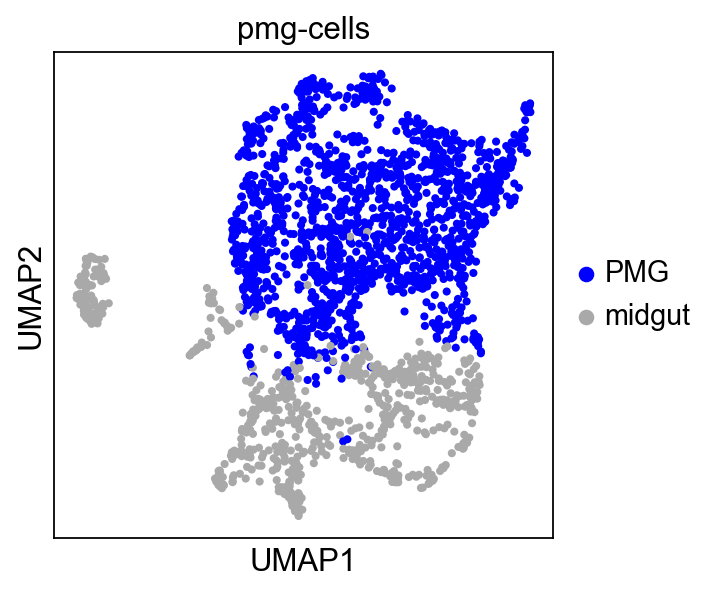

In [93]:
sc.pl.umap(wt_mg, color='pmg-cells', palette=['blue', 'darkgrey'], show=False)
plt.savefig('../figures/WT_mg_nocolor.pdf', dpi=300, bbox_inches='tight')

In [ ]:
sc.tl.leiden(wt_mg, restrict_to=['midgut_celltype', ['PMG']], resolution=0.1, key_added='pmg_sub')

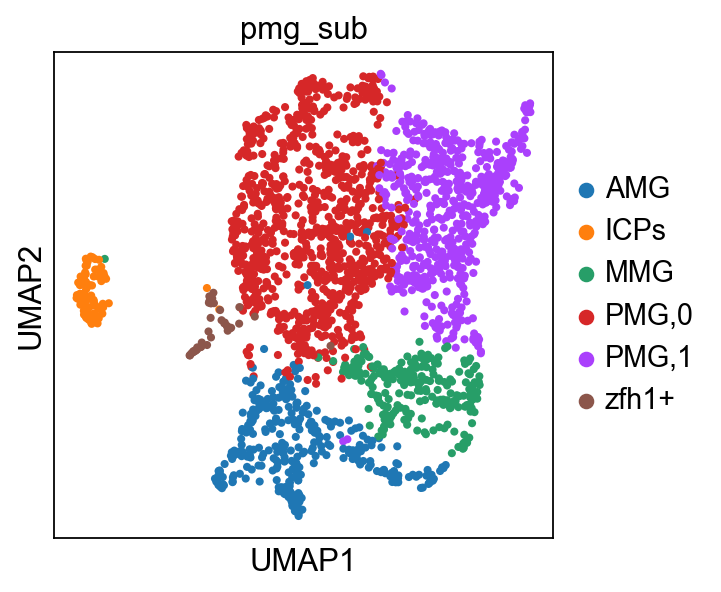

In [95]:
sc.pl.umap(wt_mg, color='pmg_sub')

In [ ]:
wt_mg.obs['pmg-cells_sub'] = wt_mg.obs['pmg_sub'].map({'PMG,0':'PMG,0', 'PMG,1':'PMG,1', 'zfh1+':'midgut', 'ICPs':'midgut', 'AMG':'midgut', 'MMG':'midgut'})

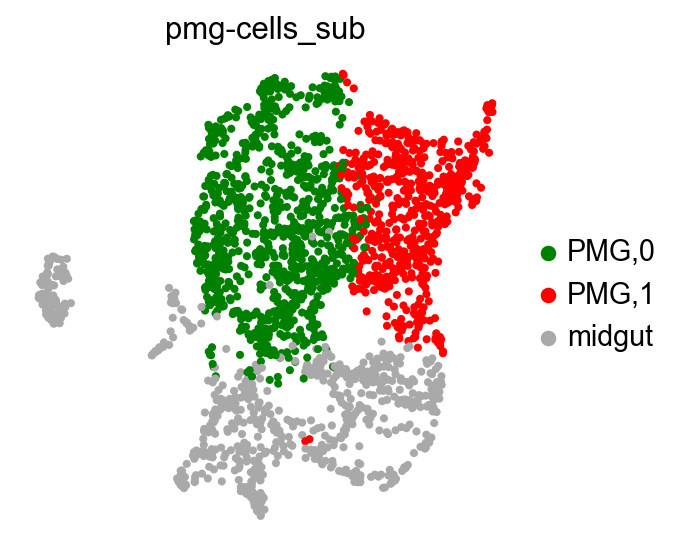

In [97]:
sc.pl.umap(wt_mg, color='pmg-cells_sub', palette=['green', 'red', 'darkgrey'], frameon=False, show=False)
plt.savefig('../figures/WT_mg_pmg_sub.pdf', dpi=300, bbox_inches='tight')